Objective:
Predict house prices using property features such as size, bedrooms, and location.

Import Libraries and Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reliable mirror for the USA Housing dataset
path = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(path)

# Displaying info to see column names and if there are missing values
print("Dataset Loaded Successfully!")
df.info()
df.head()

Dataset Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Exploratory Data Analysis (EDA) & Cleaning

Missing values after cleaning: 0


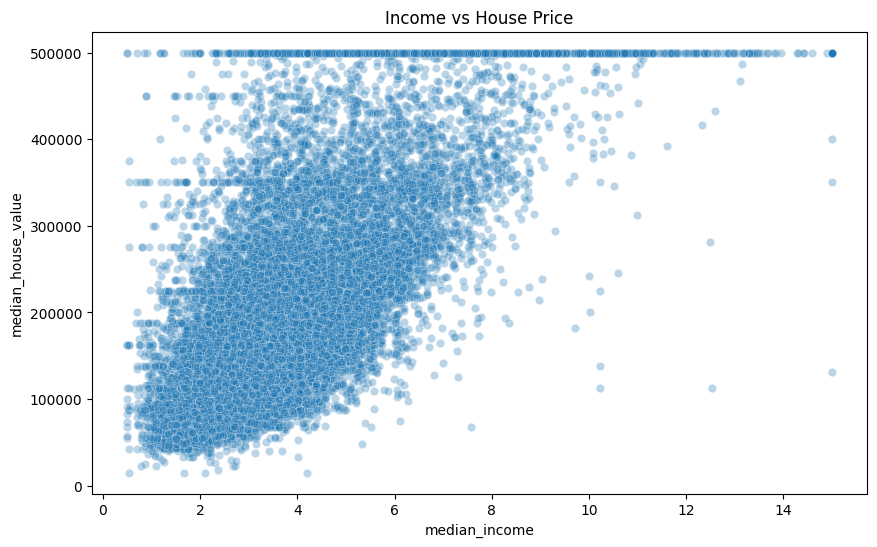

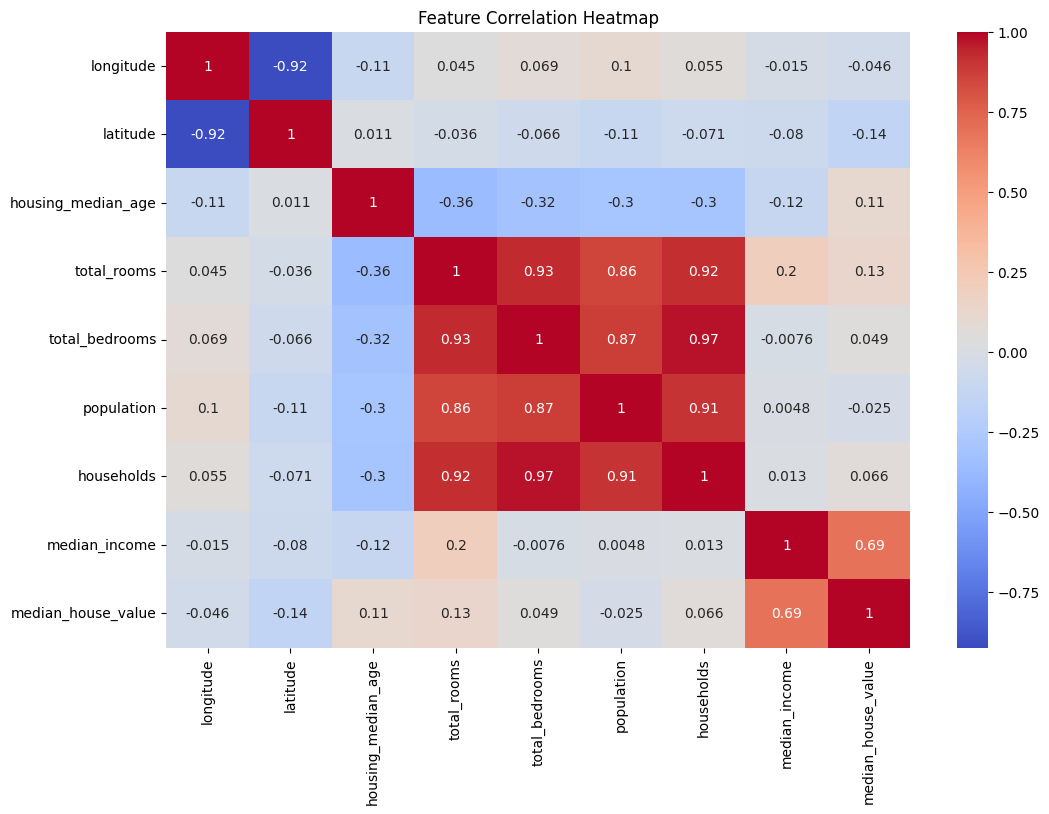

In [4]:
# 1. Fill missing values in total_bedrooms
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

# 2. Check if missing values are gone
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

# 3. Visualize the relationship between Income and House Value
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.3)
plt.title('Income vs House Price')
plt.show()

# 4. Correlation Heatmap (Numeric columns only)
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('ocean_proximity', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Feature Engineering and Encoding

In [5]:
# 1. Convert categorical 'ocean_proximity' into dummy variables (numbers)
df_final = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 2. Display the new columns
print("New Columns after Encoding:")
print(df_final.columns)

# 3. Preview the first few rows
df_final.head()

New Columns after Encoding:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


Splitting Data for Training and Testing

In [6]:
# 1. Define X (Features) and y (Target)
X = df_final.drop('median_house_value', axis=1)
y = df_final['median_house_value']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total rows in dataset: {len(df_final)}")
print(f"Rows for Training: {len(X_train)}")
print(f"Rows for Testing: {len(X_test)}")

Total rows in dataset: 20640
Rows for Training: 16512
Rows for Testing: 4128


Model Training (Linear Regression)

In [7]:
# 1. Initialize the model
model = LinearRegression()

# 2. Train (Fit) the model
model.fit(X_train, y_train)

# 3. Make predictions on the Test set
predictions = model.predict(X_test)

print("Model Training Complete!")

Model Training Complete!


Evaluation and Visualization

Mean Absolute Error: $50,670.74
Root Mean Squared Error: $70,060.52


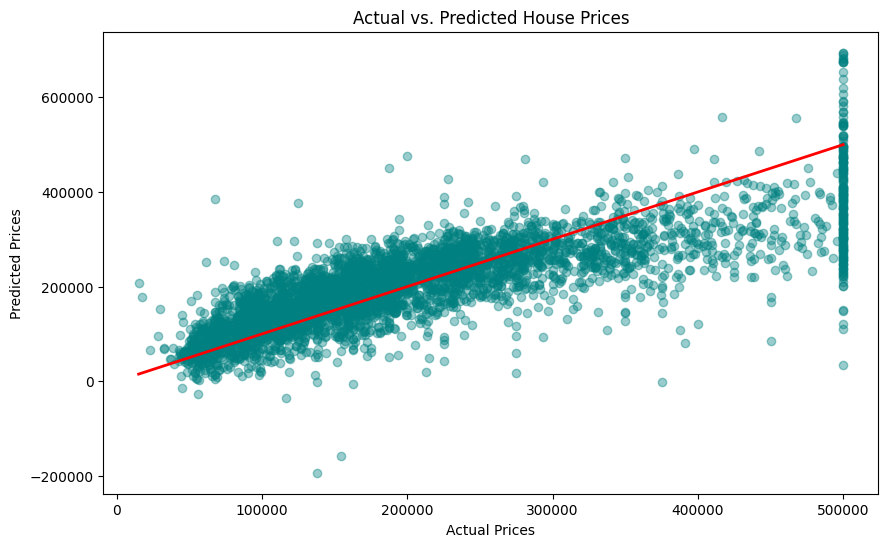

In [8]:
# 1. Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")

# 2. Visualize Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Diagonal line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted House Prices')
plt.show()

Feature Importance & Summary

In [9]:
# Create a dataframe to see the weights of each feature
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("Feature Importance (Weights):")
print(coefficients.sort_values(by='Coefficient', ascending=False))

Feature Importance (Weights):
                              Coefficient
ocean_proximity_ISLAND      136125.072615
median_income                39473.975175
ocean_proximity_NEAR OCEAN    3431.140073
housing_median_age            1102.185084
total_bedrooms                 102.789395
households                      48.252753
total_rooms                     -6.021506
population                     -38.172906
ocean_proximity_NEAR BAY     -5136.642217
latitude                    -25468.352050
longitude                   -26838.273372
ocean_proximity_INLAND      -39786.656161


Advanced Modeling: Gradient Boosting

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Initialize the Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)

# 2. Train the model
gb_model.fit(X_train, y_train)

# 3. Make predictions
gb_predictions = gb_model.predict(X_test)

# 4. Calculate new metrics
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

print(f"Gradient Boosting MAE: ${gb_mae:,.2f}")
print(f"Gradient Boosting RMSE: ${gb_rmse:,.2f}")

# 5. Compare with Linear Regression
print(f"\nImprovement in MAE: ${mae - gb_mae:,.2f}")

Gradient Boosting MAE: $35,303.60
Gradient Boosting RMSE: $52,216.26

Improvement in MAE: $15,367.14


Final Model Comparison Visual

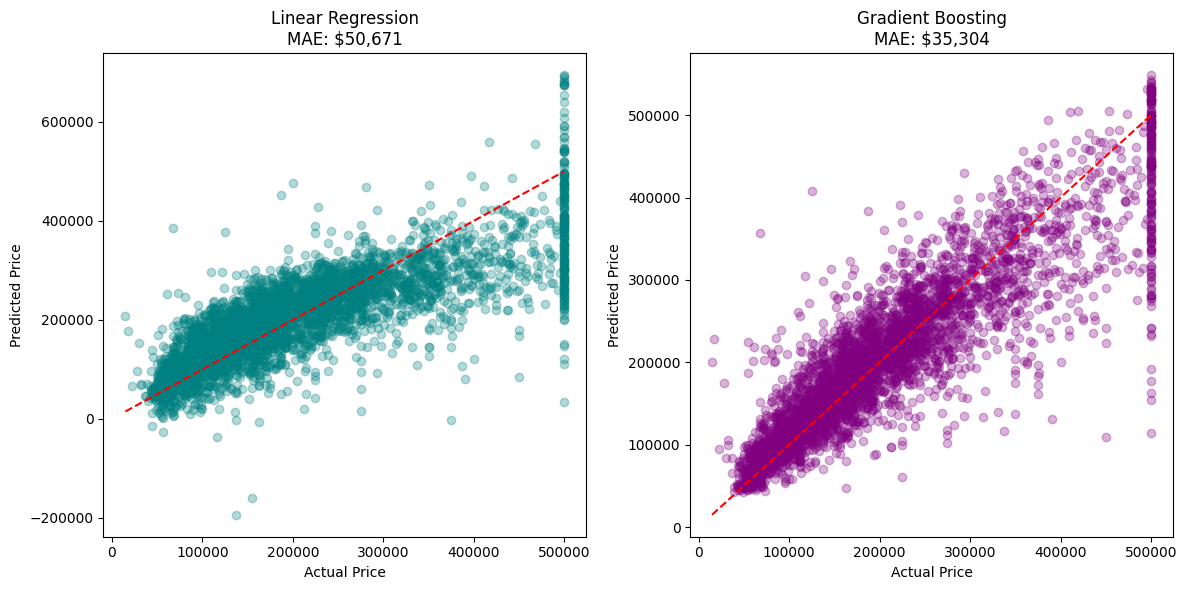

In [11]:
plt.figure(figsize=(12, 6))

# Plot 1: Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Linear Regression\nMAE: ${mae:,.0f}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Plot 2: Gradient Boosting
plt.subplot(1, 2, 2)
plt.scatter(y_test, gb_predictions, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Gradient Boosting\nMAE: ${gb_mae:,.0f}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()